# Stage 0 NPE Diagnostic

In [1]:
import numpy as np
import torch
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

torch_device = "cpu"

In [2]:
def SBC_KStest(ranks, num_posterior_samples, parameter_labels):
    num_dimensions = ranks.shape[1] 

    ks_results = []
    p_values = []
    for dim in range(num_dimensions):
        normalized_ranks = ranks[:, dim] / num_posterior_samples
        ks_stat, p_value = stats.kstest(normalized_ranks, 'uniform')
        ks_results.append(ks_stat)
        p_values.append(p_value)
    
    return ks_results, p_values


def multidim_coverage95(theta_est_post, theta_test_numpy):
    num_test_samples = theta_test_numpy.shape[0]
    joint_covered_count = 0

    for i in range(num_test_samples):
        samples = theta_est_post[i]  # Shape: (1000, 3)
        truth = theta_test_numpy[i]  # Shape: (3,)

        mean_vec = np.mean(samples, axis=0)
        cov_matrix = np.cov(samples, rowvar=False)
        
        try:
            inv_cov = np.linalg.inv(cov_matrix)
        except np.linalg.LinAlgError:
            print(f"Warning: Singular covariance matrix at index {i}, skipping.")
            continue

        diff_samples = samples - mean_vec
        dist_samples = np.sum(np.dot(diff_samples, inv_cov) * diff_samples, axis=1)

        diff_truth = truth - mean_vec
        dist_truth = np.dot(np.dot(diff_truth, inv_cov), diff_truth)

        threshold_95 = np.percentile(dist_samples, 95)

        if dist_truth <= threshold_95:
            joint_covered_count += 1

    joint_coverage_95 = joint_covered_count / num_test_samples

    return joint_coverage_95


def marginal_coverage95(theta_est_post, theta_test_numpy):
    lower_bounds = np.percentile(theta_est_post, 2.5, axis=1)
    upper_bounds = np.percentile(theta_est_post, 97.5, axis=1)
    is_covered = (theta_test_numpy >= lower_bounds) & (theta_test_numpy <= upper_bounds)
    marginal_coverages = np.mean(is_covered, axis=0)
    
    return marginal_coverages


def L2_error(theta_est_post, theta_test_numpy):
    post_mean_error = np.full((theta_est_post.shape[0]), np.nan)
    for i in range(theta_est_post.shape[0]):
        post_mean = np.mean(theta_est_post[i, :, :], axis=0)
        error = post_mean - theta_test_numpy[i, :]
        post_mean_error[i] = np.linalg.norm(error)
    return post_mean_error


def mahalanobis_error(theta_est_post, theta_test_numpy):
    maha_errors = np.full((theta_est_post.shape[0]), np.nan)
    for i in range(theta_est_post.shape[0]):
        samples = theta_est_post[i]
        truth = theta_test_numpy[i]
        post_mean = np.mean(samples, axis=0)
        cov_matrix = np.cov(samples, rowvar=False)

        try:
            inv_cov = np.linalg.inv(cov_matrix)
        except np.linalg.LinAlgError:
            print(f"Warning: Singular covariance matrix at index {i}, returning NaN.")
            continue
        
        diff = post_mean - truth
        maha_dist_sq = np.dot(np.dot(diff, inv_cov), diff)
        maha_errors[i] = np.sqrt(maha_dist_sq)
    return maha_errors

In [3]:
drop_col = range(16, 32)
theta_test = np.loadtxt(str('../../data/ClonalOrigin/rho_and_theta/theta_sbc.csv'), delimiter=",")
x_test = np.loadtxt(str('../../data/ClonalOrigin/rho_and_theta/x_sbc.csv'), delimiter=",")

theta_test = torch.tensor(theta_test, device=torch_device)
theta_test = theta_test.to(torch.float32)
theta_test_numpy = theta_test.cpu().numpy()

x_test = np.delete(x_test, drop_col, axis=1)
x_test = torch.tensor(x_test, device=torch_device)
x_test = x_test.to(torch.float32)
x_test_numpy = x_test.cpu().numpy()

nan_row = np.where(np.isnan(x_test_numpy))[0]
theta_test = theta_test[~np.isnan(x_test_numpy).any(axis=1)]
x_test = x_test[~np.isnan(x_test_numpy).any(axis=1)]

theta_test_numpy = theta_test.cpu().numpy()
x_test_numpy = x_test.cpu().numpy()

print(theta_test.shape, x_test.shape)

torch.Size([998, 3]) torch.Size([998, 30])


In [4]:
sim_budgets = ['200', '500', '1000', '2000', '5000', '10000', '50000']
num_budgets = [200, 500, 1000, 2000, 5000, 10000, 49948]
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
stage0_marginal_coverage = np.full((3, 7, 10), np.nan)
stage0_multidim_coverage = np.full((7, 10), np.nan)
stage0_L2_error = np.full((998, 7, 10), np.nan)
stage0_L2_noL = np.full((998, 7, 10), np.nan)
stage0_mahalanobis_error = np.full((998, 7, 10), np.nan)
stage0_sbc_D = np.full((3, 7, 10), np.nan)
stage0_sbc_p_values = np.full((3, 7, 10), np.nan)

In [5]:
for i in range(len(seeds)):
    seed = seeds[i]

    for j in range(len(num_budgets)):
        n_sim = num_budgets[j]
        post_filename = f"../../data/post_diagnostic/npe_post_seed{seed}_sim{n_sim}.npy"
        theta_est_post = np.load(post_filename)
        print(f"Loaded posterior samples for seed {seed} and n_sim {n_sim}: shape {theta_est_post.shape}")

        parameter_labels = [r"for $\rho_s$", r"for $\theta_s$", r"for L"]
        theta_test_expanded = theta_test.unsqueeze(1)
        theta_est_post_tensor = torch.tensor(theta_est_post, device=torch_device)
        theta_est_post_tensor = theta_est_post_tensor.to(torch.float32)
        is_less_than_truth = theta_est_post_tensor < theta_test_expanded
        ranks = torch.sum(is_less_than_truth, dim=1)
        ks_results, p_values = SBC_KStest(ranks, 500, parameter_labels)
        stage0_sbc_D[:, j, i] = ks_results
        stage0_sbc_p_values[:, j, i] = p_values

        stage0_multidim_coverage[j, i] = multidim_coverage95(theta_est_post, theta_test_numpy)
        stage0_marginal_coverage[:, j, i] = marginal_coverage95(theta_est_post, theta_test_numpy)

        stage0_L2_error[:, j, i] = L2_error(theta_est_post, theta_test_numpy)
        stage0_L2_noL[:, j, i] = L2_error(theta_est_post[:, :, :2], theta_test_numpy[:, :2])
        stage0_mahalanobis_error[:, j, i] = mahalanobis_error(theta_est_post, theta_test_numpy)


Loaded posterior samples for seed 1 and n_sim 200: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 500: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 1000: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 2000: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 5000: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 10000: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 200: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 500: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 1000: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 2000: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 5000: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 10000: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 49948: shape (998, 

## Figures

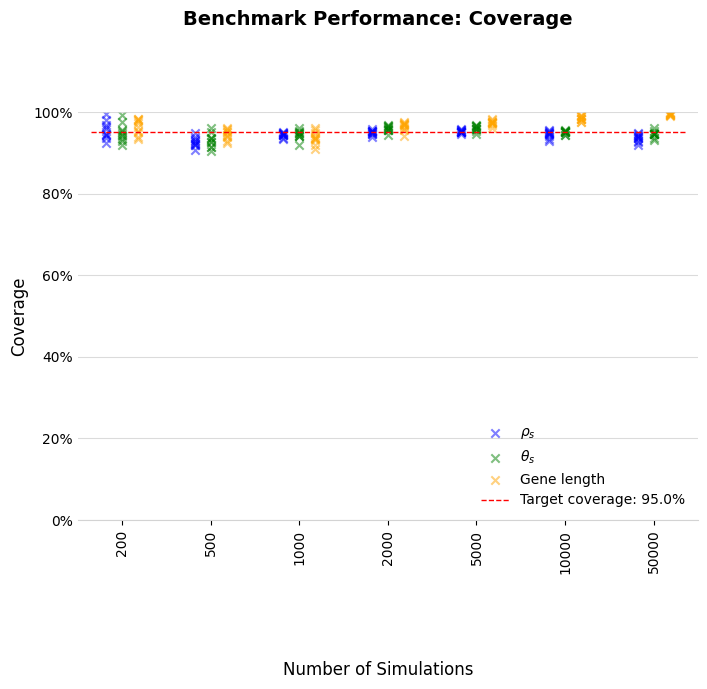

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: Coverage', fontsize=14, fontweight='bold', y=1.05)

results = stage0_marginal_coverage
x_base = np.arange(len(sim_budgets))
x = np.repeat(x_base, 10)
offsets = [-0.18, 0.0, 0.18]

y1 = results[0, :, :].flatten()
y2 = results[1, :, :].flatten()
y3 = results[2, :, :].flatten()

ax.scatter(x + offsets[0], y1, marker='x', color='blue', alpha=0.5, label=r'$\rho_s$')
ax.scatter(x + offsets[1], y2, marker='x', color='green', alpha=0.5, label=r'$\theta_s$')
ax.scatter(x + offsets[2], y3, marker='x', color='orange', alpha=0.5, label='Gene length')

ax.hlines(
    y=0.95,
    xmin=x_base[0] - 0.35,
    xmax=x_base[-1] + 0.35,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Target coverage: 95.0%'
)

ax.set_xticks(x_base)
ax.set_xticklabels(sim_budgets, rotation=90)
ax.set_xlim(x_base[0] - 0.5, x_base[-1] + 0.5)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')

ax.tick_params(axis='y', length=0)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

ax.set_ylabel('Coverage', fontsize=12)
ax.legend(loc='lower right', fontsize=10, frameon=False)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.ylim(0, 1)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

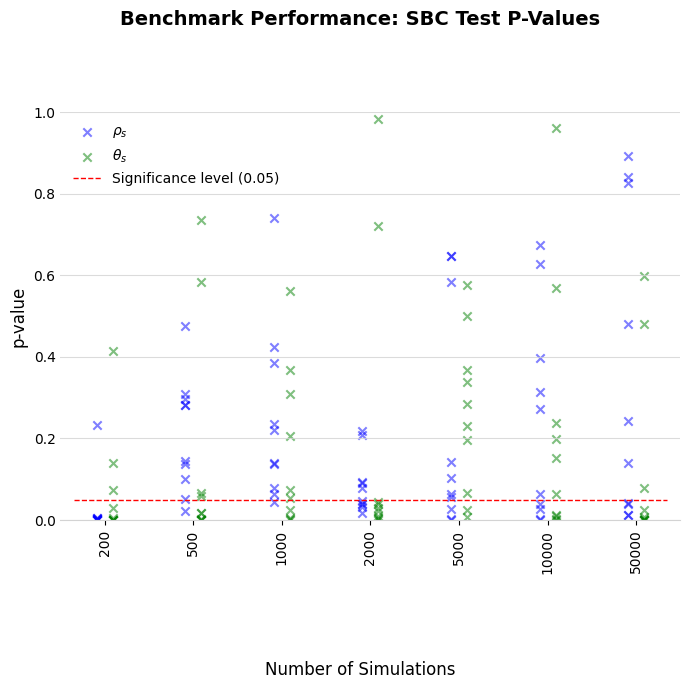

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: SBC Test P-Values', fontsize=14, fontweight='bold', y=1.05)

results = stage0_sbc_p_values
x_base = np.arange(len(sim_budgets))
x = np.repeat(x_base, 10)
offsets = [-0.09, 0.09]

y1 = results[0, :, :].flatten()
y2 = results[1, :, :].flatten()

ax.scatter(x + offsets[0], y1, marker='x', color='blue', alpha=0.5, label=r'$\rho_s$')
ax.scatter(x + offsets[1], y2, marker='x', color='green', alpha=0.5, label=r'$\theta_s$')

ax.hlines(
    y=0.05,
    xmin=x_base[0] - 0.35,
    xmax=x_base[-1] + 0.35,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Significance level (0.05)'
)

ax.set_xticks(x_base)
ax.set_xticklabels(sim_budgets, rotation=90)
ax.set_xlim(x_base[0] - 0.5, x_base[-1] + 0.5)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')

ax.tick_params(axis='y', length=0)

ax.set_ylabel('p-value', fontsize=12)
ax.legend(loc='upper left', fontsize=10, frameon=False)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.ylim(0, 1)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

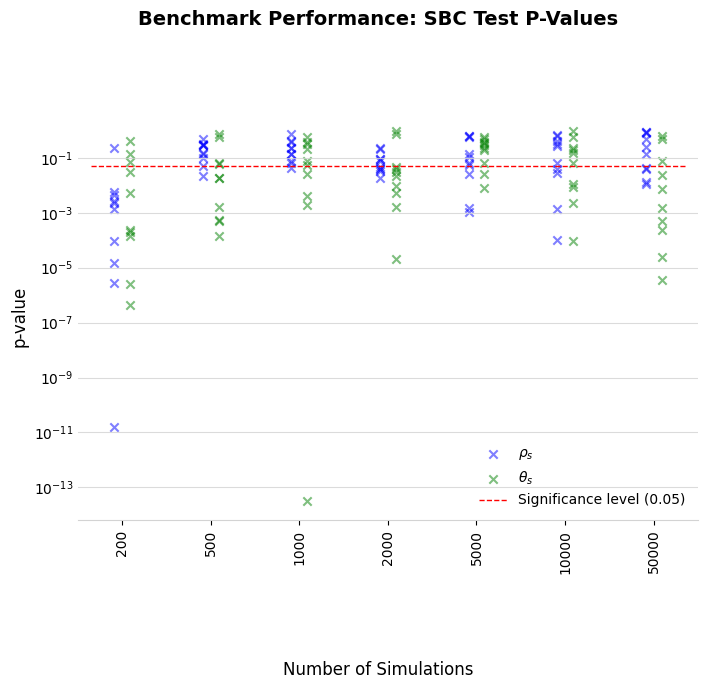

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: SBC Test P-Values', fontsize=14, fontweight='bold', y=1.05)

results = stage0_sbc_p_values
x_base = np.arange(len(sim_budgets))
x = np.repeat(x_base, 10)
offsets = [-0.09, 0.09]

y1 = results[0, :, :].flatten()
y2 = results[1, :, :].flatten()

ax.scatter(x + offsets[0], y1, marker='x', color='blue', alpha=0.5, label=r'$\rho_s$')
ax.scatter(x + offsets[1], y2, marker='x', color='green', alpha=0.5, label=r'$\theta_s$')

ax.hlines(
    y=0.05,
    xmin=x_base[0] - 0.35,
    xmax=x_base[-1] + 0.35,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Significance level (0.05)'
)

ax.set_xticks(x_base)
ax.set_xticklabels(sim_budgets, rotation=90)
ax.set_xlim(x_base[0] - 0.5, x_base[-1] + 0.5)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')

ax.tick_params(axis='y', length=0)
ax.set_yscale('log')

ax.set_ylabel('p-value', fontsize=12)
ax.legend(loc='lower right', fontsize=10, frameon=False)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

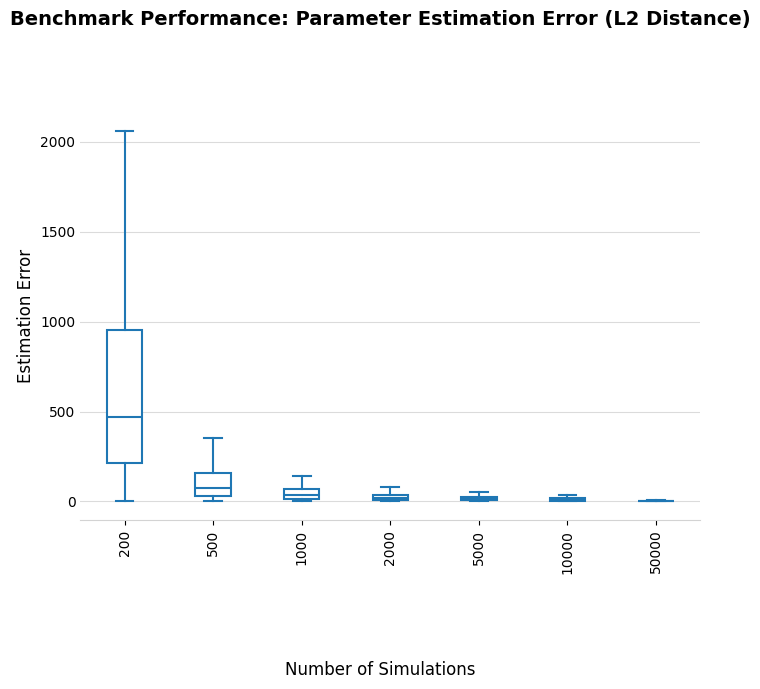

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: Parameter Estimation Error (L2 Distance)', fontsize=14, fontweight='bold', y=1.05)

raw_results = stage0_L2_error
x_positions = np.arange(len(sim_budgets))

arr = raw_results
arr_swapped = np.swapaxes(arr, 1, 2)
arr_flat = arr_swapped.reshape(-1, 7)

bplot = ax.boxplot(
    arr_flat,
    positions=x_positions,
    patch_artist=True,
    widths=0.4,
    showfliers=False
)

for patch in bplot['boxes']:
    patch.set_facecolor('white')
    patch.set_edgecolor('#1f77b4')
    patch.set_linewidth(1.5)
    
for element in ['whiskers', 'caps', 'medians']:
    for line in bplot[element]:
        line.set_color('#1f77b4')
        line.set_linewidth(1.5)

ax.set_xticks(x_positions)
ax.set_xticklabels(sim_budgets, rotation=90)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.tick_params(axis='y', length=0)

ax.set_ylabel(r'Estimation Error', fontsize=12)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

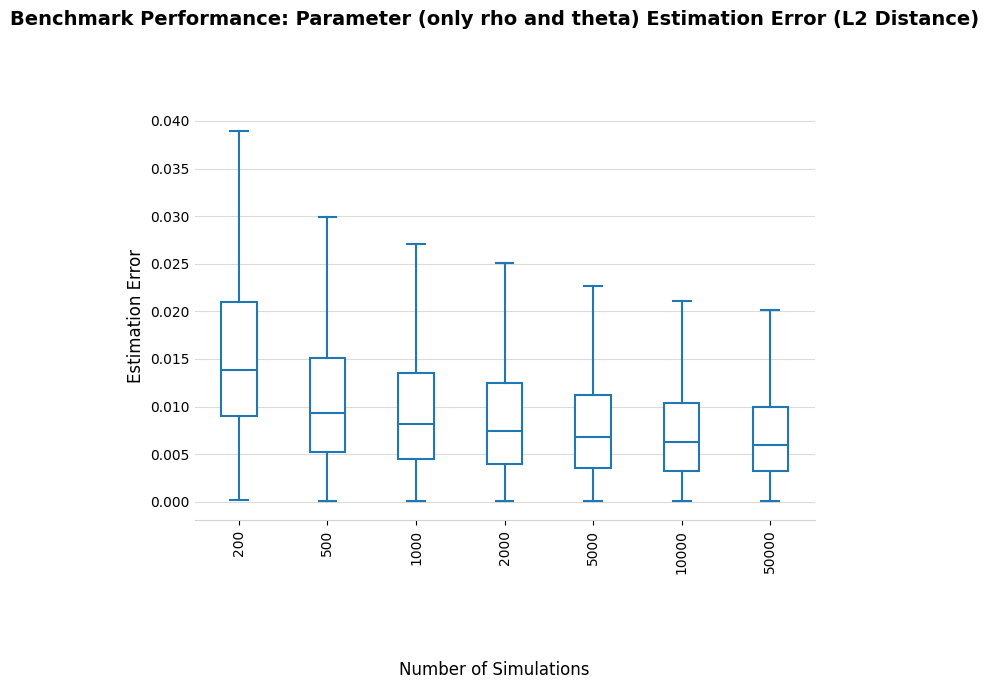

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: Parameter (only rho and theta) Estimation Error (L2 Distance)', fontsize=14, fontweight='bold', y=1.05)

raw_results = stage0_L2_noL
x_positions = np.arange(len(sim_budgets))

arr = raw_results
arr_swapped = np.swapaxes(arr, 1, 2)
arr_flat = arr_swapped.reshape(-1, 7)

bplot = ax.boxplot(
    arr_flat,
    positions=x_positions,
    patch_artist=True,
    widths=0.4,
    showfliers=False
)

for patch in bplot['boxes']:
    patch.set_facecolor('white')
    patch.set_edgecolor('#1f77b4')
    patch.set_linewidth(1.5)
    
for element in ['whiskers', 'caps', 'medians']:
    for line in bplot[element]:
        line.set_color('#1f77b4')
        line.set_linewidth(1.5)

ax.set_xticks(x_positions)
ax.set_xticklabels(sim_budgets, rotation=90)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.tick_params(axis='y', length=0)

ax.set_ylabel(r'Estimation Error', fontsize=12)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

In [12]:
last_sim_p_values = stage0_sbc_p_values[:, -1, :]
last_sim_p_values.shape

(3, 10)

In [13]:
miscal_indices = np.where((last_sim_p_values[0, :] < 0.05) | (last_sim_p_values[1, :] < 0.05))[0]
miscal_indices

array([0, 2, 3, 4, 5, 6, 7, 8])

In [14]:
def plot_sbc_ecdf_diff(ranks, num_posterior_samples, param_names=None):
    """
    Plots the ECDF Difference plot for SBC ranks.
    """
    ranks_np = np.array(ranks)
    num_sims, num_params = ranks_np.shape
    
    plt.figure(figsize=(10, 8))

    x_eval = np.linspace(0, 1, 1000)

    std_err = np.sqrt(x_eval * (1 - x_eval) / num_sims)
    envelope_upper = 1.96 * std_err
    envelope_lower = -1.96 * std_err

    plt.fill_between(x_eval, envelope_lower, envelope_upper, color='grey', alpha=0.3, label='95% Confidence')
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

    for i in range(num_params):
        param_ranks = ranks_np[:, i] / num_posterior_samples

        empirical_cdf = np.searchsorted(np.sort(param_ranks), x_eval, side='right') / num_sims

        diff = empirical_cdf - x_eval
        
        label = param_names[i] if param_names else f'Param {i}'
        plt.plot(x_eval, diff, label=label, linewidth=2)

    plt.title("SBC ECDF Difference Plot")
    plt.xlabel("Fractional Rank")
    plt.ylabel("Difference from Uniform CDF")
    plt.legend(frameon=False)
    plt.show()

Loaded posterior samples for seed 1 and n_sim 49948: shape (998, 500, 3)


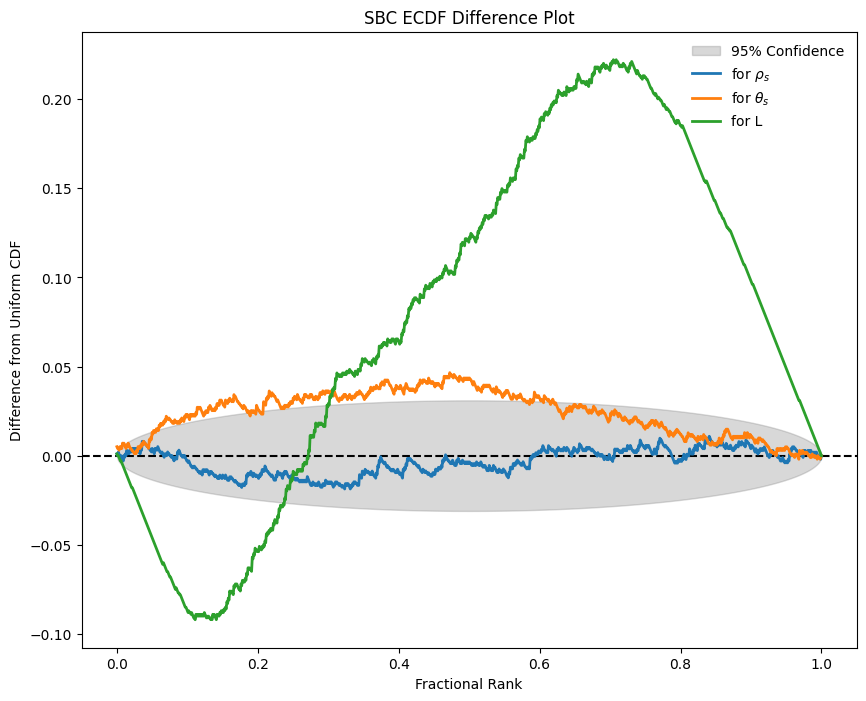

Loaded posterior samples for seed 3 and n_sim 49948: shape (998, 500, 3)


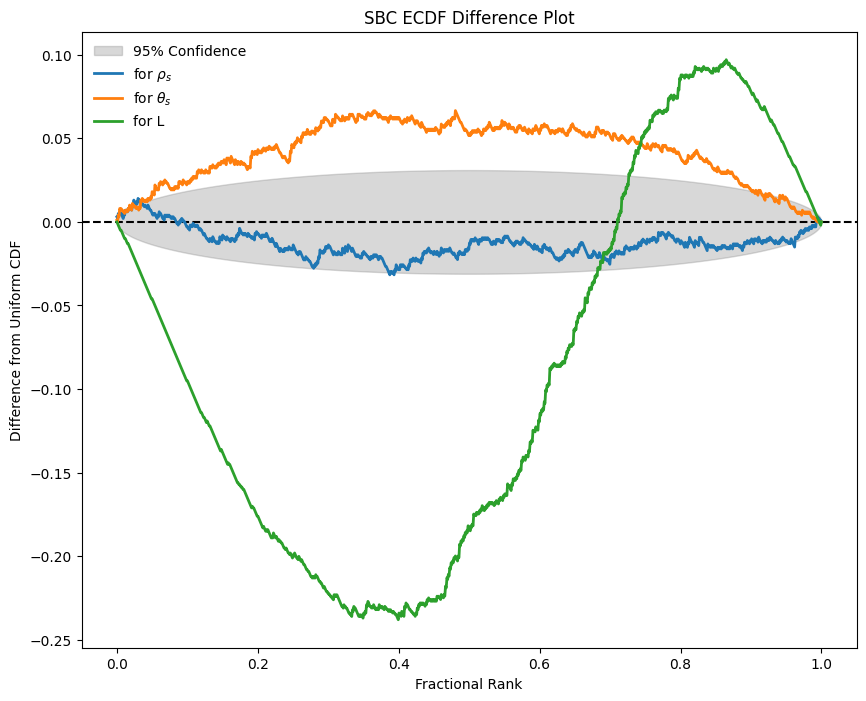

Loaded posterior samples for seed 4 and n_sim 49948: shape (998, 500, 3)


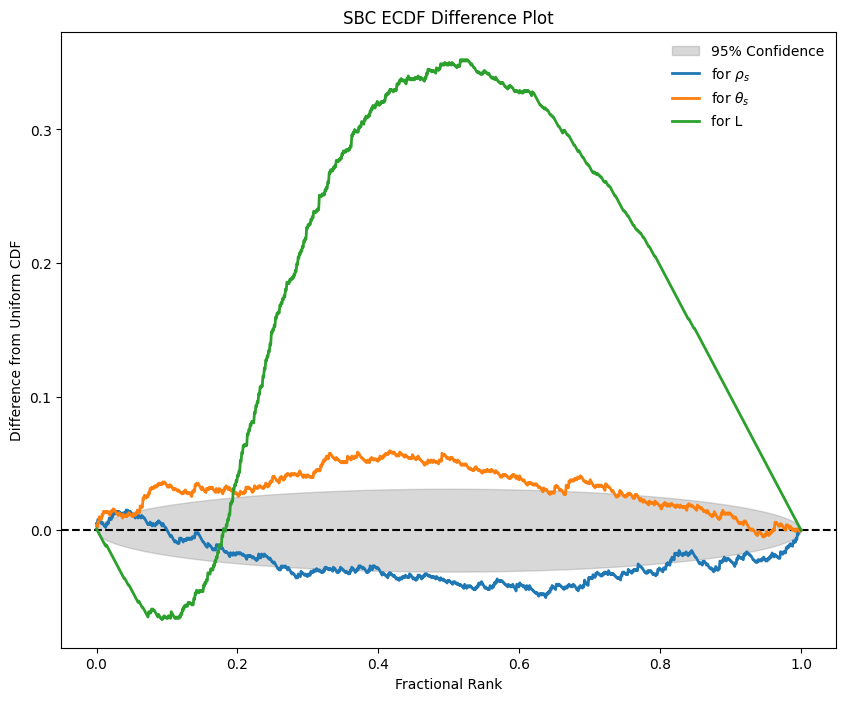

Loaded posterior samples for seed 5 and n_sim 49948: shape (998, 500, 3)


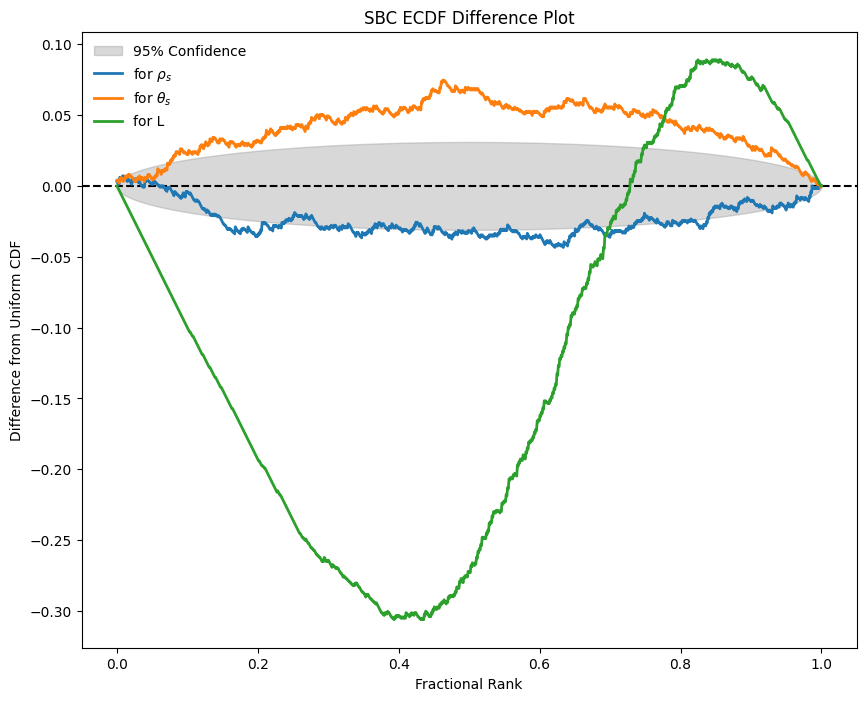

Loaded posterior samples for seed 6 and n_sim 49948: shape (998, 500, 3)


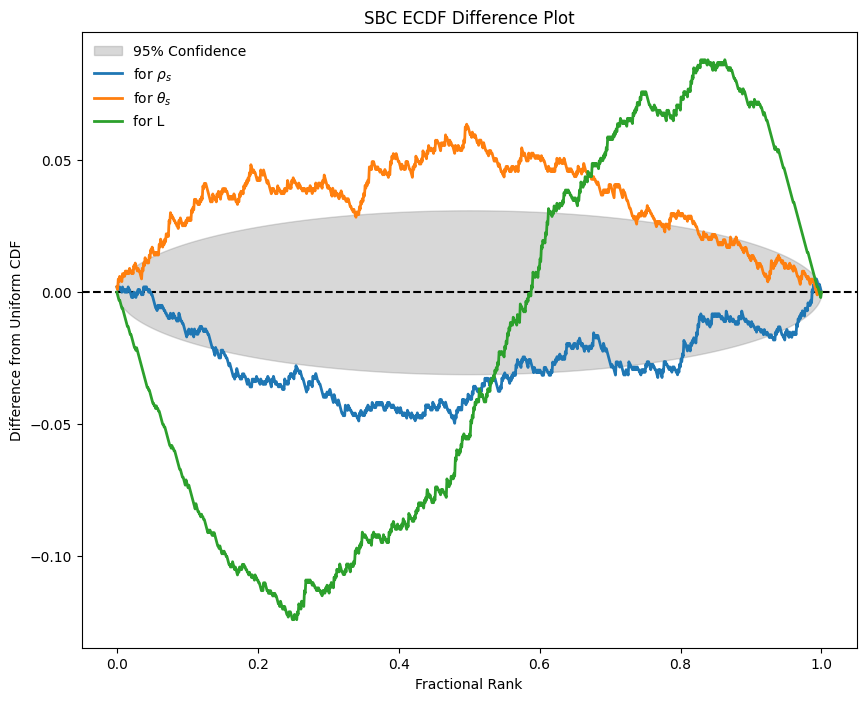

Loaded posterior samples for seed 7 and n_sim 49948: shape (998, 500, 3)


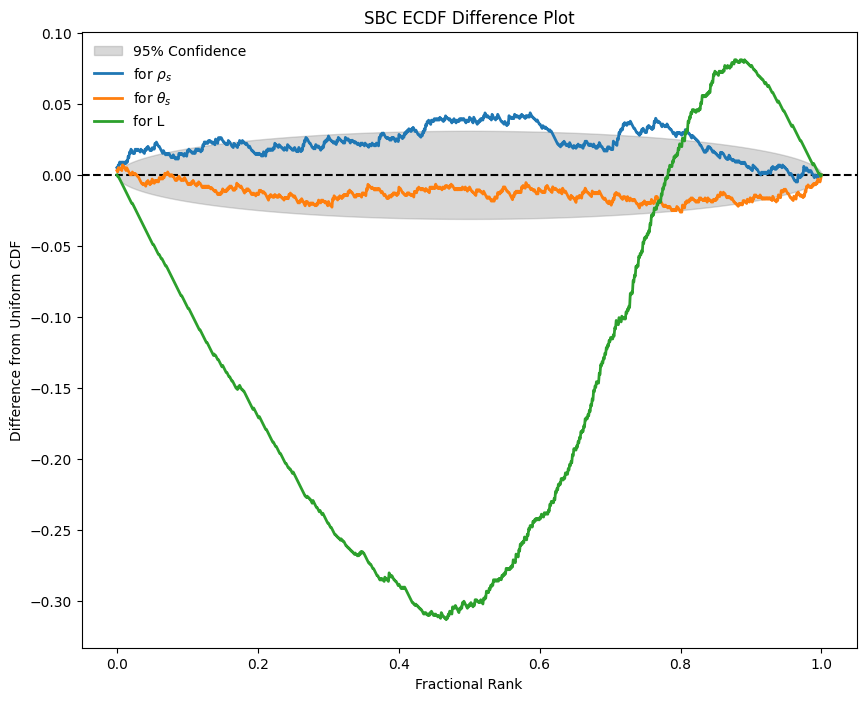

Loaded posterior samples for seed 8 and n_sim 49948: shape (998, 500, 3)


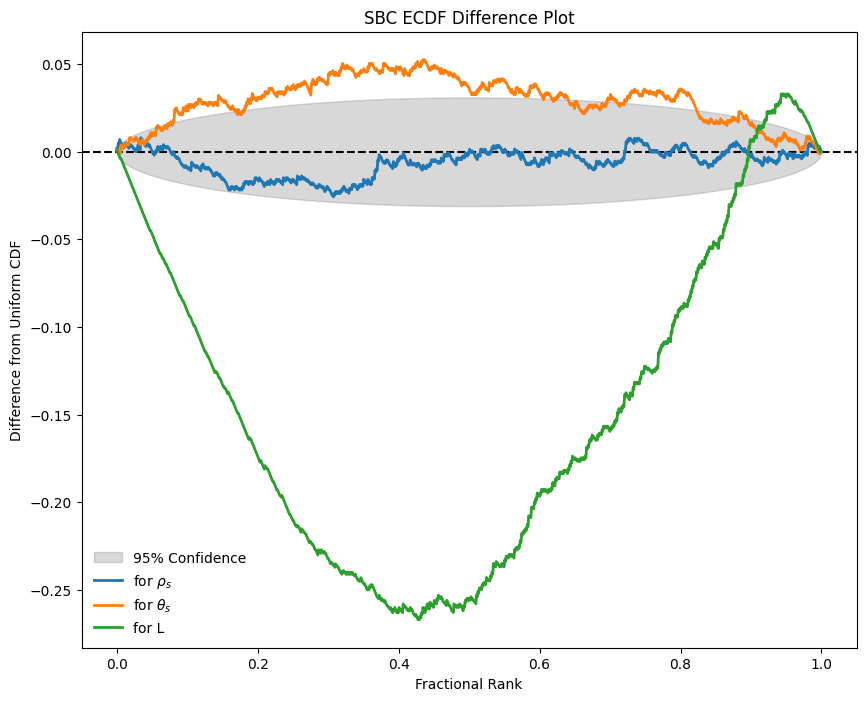

Loaded posterior samples for seed 9 and n_sim 49948: shape (998, 500, 3)


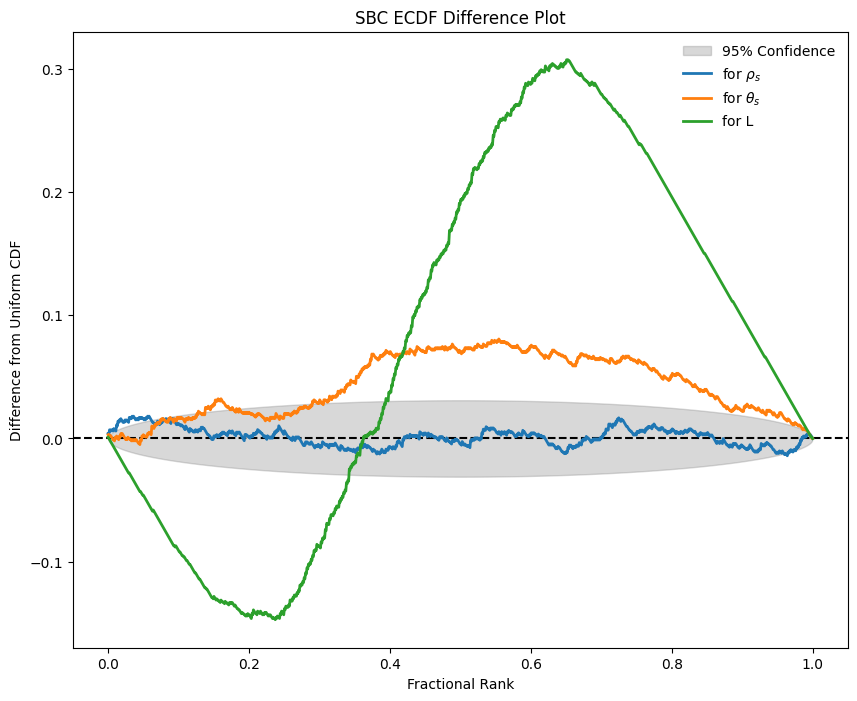

In [15]:
for i in miscal_indices:
    seed = seeds[i]
    n_sim = num_budgets[-1]
    post_filename = f"../../data/post_diagnostic/npe_post_seed{seed}_sim{n_sim}.npy"
    theta_est_post = np.load(post_filename)
    print(f"Loaded posterior samples for seed {seed} and n_sim {n_sim}: shape {theta_est_post.shape}")

    parameter_labels = [r"for $\rho_s$", r"for $\theta_s$", r"for L"]
    theta_test_expanded = theta_test.unsqueeze(1)
    theta_est_post_tensor = torch.tensor(theta_est_post, device=torch_device)
    theta_est_post_tensor = theta_est_post_tensor.to(torch.float32)
    is_less_than_truth = theta_est_post_tensor < theta_test_expanded
    ranks = torch.sum(is_less_than_truth, dim=1)
    plot_sbc_ecdf_diff(ranks.cpu().numpy(), 500, param_names=parameter_labels)

## Transform theta

In [16]:
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
stage0_logit_marginal_coverage = np.full((3, 10), np.nan)
stage0_logit_multidim_coverage = np.full((10), np.nan)
stage0_logit_L2_error = np.full((998, 10), np.nan)
stage0_logit_L2_noL = np.full((998, 10), np.nan)
stage0_logit_mahalanobis_error = np.full((998, 10), np.nan)
stage0_logit_sbc_D = np.full((3, 10), np.nan)
stage0_logit_sbc_p_values = np.full((3, 10), np.nan)

In [17]:
def bounded_to_logit(
    theta: torch.Tensor,
    low: torch.Tensor,
    high: torch.Tensor,
    eps: float = 1e-6,
) -> torch.Tensor:
    """
    Transform bounded parameters from [low, high] to (-inf, inf).

    theta: shape (..., num_parameters)
    low:   shape (num_parameters,)
    high:  shape (num_parameters,)
    """
    low = low.to(device=theta.device, dtype=theta.dtype)
    high = high.to(device=theta.device, dtype=theta.dtype)

    if torch.any(high <= low):
        raise ValueError("Each upper bound must be greater than its lower bound.")

    u = (theta - low) / (high - low)

    if torch.any((u < 0) | (u > 1)):
        raise ValueError("Some theta values are outside the specified bounds.")

    u = u.clamp(min=eps, max=1.0 - eps)

    return torch.logit(u)


def logit_to_bounded(
    theta_logit: torch.Tensor,
    low: torch.Tensor,
    high: torch.Tensor,
) -> torch.Tensor:
    """
    Transform parameters from (-inf, inf) back to [low, high].
    """
    low = low.to(device=theta_logit.device, dtype=theta_logit.dtype)
    high = high.to(device=theta_logit.device, dtype=theta_logit.dtype)

    return low + (high - low) * torch.sigmoid(theta_logit)

In [18]:
low = torch.tensor(
    [0.0, 0.0, 100.0],
    device=theta_test.device,
    dtype=theta_test.dtype,
)

high = torch.tensor(
    [0.1, 0.1, 10000.0],
    device=theta_test.device,
    dtype=theta_test.dtype,
)

In [19]:
for i in range(len(seeds)):
    seed = seeds[i]
    n_sim = 49948
    post_filename = f"../../data/benchmark_extension/npe_post_seed{seed}_sim{n_sim}_logit.npy"
    theta_est_post = np.load(post_filename)
    print(f"Loaded posterior samples for seed {seed} and n_sim {n_sim}: shape {theta_est_post.shape}")

    theta_est_post_back = np.full(theta_est_post.shape, np.nan)
    for j in range(theta_est_post.shape[0]):
        theta_iter_tensor = torch.tensor(theta_est_post[j, :, :], device=theta_test.device, dtype=theta_test.dtype)
        theta_iter_back = logit_to_bounded(
            theta_logit=theta_iter_tensor,
            low=low,
            high=high,
        )
        theta_est_post_back[j, :, :] = theta_iter_back.cpu().numpy()

    parameter_labels = [r"for $\rho_s$", r"for $\theta_s$", r"for L"]
    theta_test_expanded = theta_test.unsqueeze(1)
    theta_est_post_tensor = torch.tensor(theta_est_post_back, device=torch_device)
    theta_est_post_tensor = theta_est_post_tensor.to(torch.float32)
    is_less_than_truth = theta_est_post_tensor < theta_test_expanded
    ranks = torch.sum(is_less_than_truth, dim=1)
    ks_results, p_values = SBC_KStest(ranks, 500, parameter_labels)
    stage0_logit_sbc_D[:, i] = ks_results
    stage0_logit_sbc_p_values[:, i] = p_values

    stage0_logit_multidim_coverage[i] = multidim_coverage95(theta_est_post_back, theta_test_numpy)
    stage0_logit_marginal_coverage[:, i] = marginal_coverage95(theta_est_post_back, theta_test_numpy)

    stage0_logit_L2_error[:, i] = L2_error(theta_est_post_back, theta_test_numpy)
    stage0_logit_L2_noL[:, i] = L2_error(theta_est_post_back[:, :, :2], theta_test_numpy[:, :2])
    stage0_logit_mahalanobis_error[:, i] = mahalanobis_error(theta_est_post_back, theta_test_numpy)


Loaded posterior samples for seed 1 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 3 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 4 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 5 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 6 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 7 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 8 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 9 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 10 and n_sim 49948: shape (998, 500, 3)


In [20]:
print(stage0_logit_sbc_p_values)

[[8.69411363e-001 3.47225004e-001 1.85133901e-002 7.96243075e-001
  8.51084009e-001 6.55829103e-001 3.05978867e-001 6.65271892e-002
  2.19510220e-001 1.70305909e-004]
 [5.24060907e-006 2.81694997e-002 3.20916905e-001 1.80429840e-003
  6.02764629e-001 6.69495256e-001 9.21834979e-002 5.05746603e-001
  2.28936828e-003 3.10192633e-002]
 [4.87834926e-102 2.32013266e-078 4.99157349e-066 5.74307068e-017
  2.07542079e-024 3.48864565e-118 1.59429034e-071 4.74206304e-028
  2.16963879e-060 8.39346651e-043]]


In [21]:
miscal_indices_logit = np.where((stage0_logit_sbc_p_values[0] < 0.05) | (stage0_logit_sbc_p_values[1] < 0.05))[0]
miscal_indices_logit

array([0, 1, 2, 3, 8, 9])

In [22]:
print(stage0_logit_marginal_coverage)

[[0.94088176 0.93587174 0.93787575 0.94288577 0.93086172 0.94288577
  0.94388778 0.9238477  0.93987976 0.93587174]
 [0.94589178 0.94689379 0.95190381 0.94789579 0.94589178 0.94689379
  0.9488978  0.94088176 0.94689379 0.95490982]
 [0.98196393 0.98697395 0.98396794 0.98396794 0.97695391 0.97895792
  0.97995992 0.98396794 0.98597194 0.98396794]]


In [23]:
print(stage0_logit_L2_error)

[[9.53950802e+01 2.19813717e+00 1.01028121e+01 ... 3.79990936e+01
  2.80167381e+01 1.88502085e+00]
 [1.60552651e+01 2.81946599e+01 4.00830413e+01 ... 5.38654880e+01
  7.51561229e+00 3.79156277e+01]
 [2.16713667e+01 3.94893502e+00 1.40295031e+02 ... 2.58837682e-02
  1.44967003e+01 3.81092527e+01]
 ...
 [3.85180268e+01 3.34371356e+01 2.13883791e+01 ... 9.99174692e+00
  5.04627861e+01 4.48877732e+00]
 [8.83713325e+01 4.63791370e+01 7.09538009e+00 ... 1.32807651e+01
  1.80454509e+01 5.41529324e+01]
 [3.48182713e+01 1.01427164e+01 1.80746198e+01 ... 6.04765929e+01
  4.58328604e+00 1.34970449e+01]]


### Compare marginal coverage

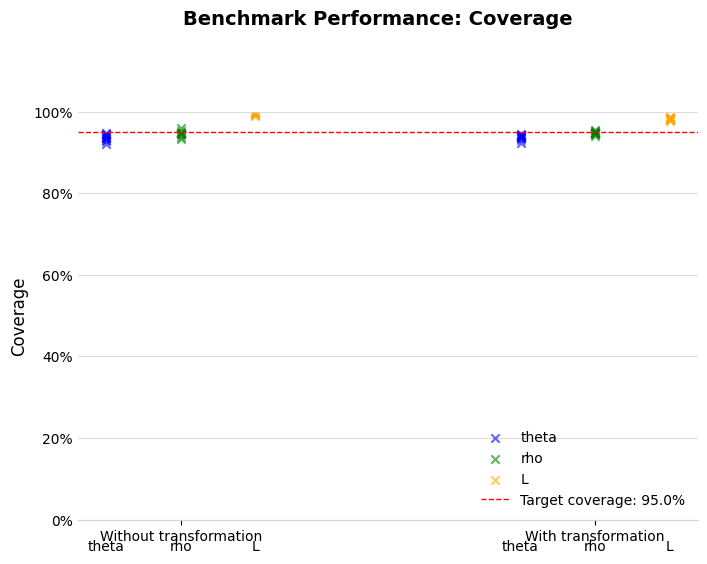

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: Coverage', fontsize=14, fontweight='bold', y=1.05)

x_groups = ['Without transformation', 'With transformation']
x_pos = np.arange(len(x_groups))
offsets = {
    'theta': -0.18,
    'rho': 0.00,
    'L': 0.18,
}

colors = {
    'theta': 'blue',
    'rho': 'green',
    'L': 'orange',
}

without_transform = {
    'theta': stage0_marginal_coverage[0, 6, :],
    'rho': stage0_marginal_coverage[1, 6, :],
    'L': stage0_marginal_coverage[2, 6, :],
}

with_transform = {
    'theta': stage0_logit_marginal_coverage[0, :],
    'rho': stage0_logit_marginal_coverage[1, :],
    'L': stage0_logit_marginal_coverage[2, :],
}
for label in ['theta', 'rho', 'L']:
    y_without = without_transform[label]
    y_with = with_transform[label]

    x_without = np.repeat(x_pos[0] + offsets[label], len(y_without))
    x_with = np.repeat(x_pos[1] + offsets[label], len(y_with))

    ax.scatter(
        x_without,
        y_without,
        marker='x',
        color=colors[label],
        alpha=0.6,
        label=label,
    )

    ax.scatter(
        x_with,
        y_with,
        marker='x',
        color=colors[label],
        alpha=0.6,
    )

ax.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Target coverage: 95.0%'
)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_groups, rotation=0)
for group_x in x_pos:
    for label, offset in offsets.items():
        ax.text(
            group_x + offset,
            -0.05,
            label,
            ha='center',
            va='top',
            fontsize=10,
            transform=ax.get_xaxis_transform()
        )

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')

ax.tick_params(axis='y', length=0)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

ax.set_ylabel('Coverage', fontsize=12)
ax.legend(loc='lower right', fontsize=10, frameon=False)

plt.ylim(0, 1)
plt.subplots_adjust(bottom=0.2)
plt.show()

### Compare errors

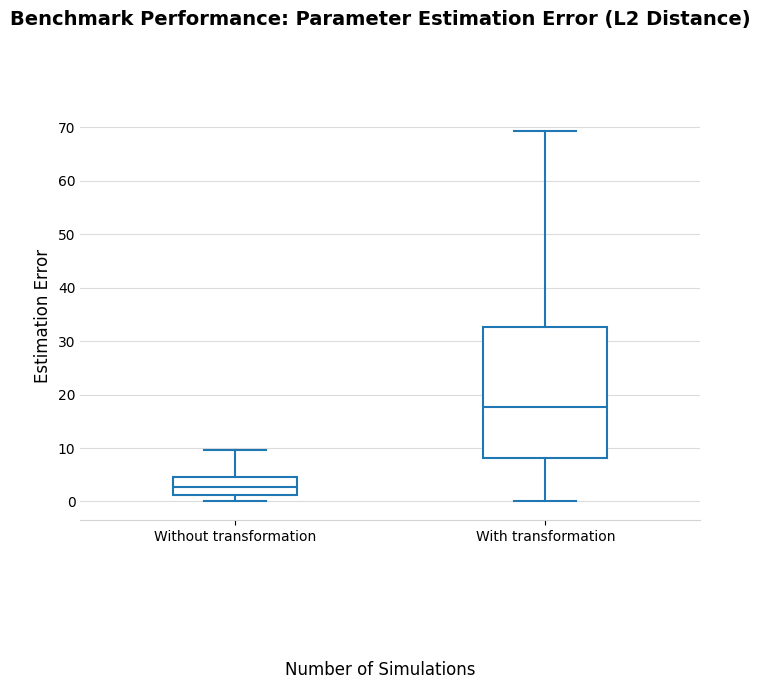

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: Parameter Estimation Error (L2 Distance)', fontsize=14, fontweight='bold', y=1.05)

raw_results = np.array([stage0_L2_error[:, 6, :], stage0_logit_L2_error])
x_positions = [0, 1]

arr = raw_results.copy()
arr_swapped = np.swapaxes(arr, 0, 2)
arr_flat = arr_swapped.reshape(-1, 2)

bplot = ax.boxplot(
    arr_flat,
    positions=x_positions,
    patch_artist=True,
    widths=0.4,
    showfliers=False
)

for patch in bplot['boxes']:
    patch.set_facecolor('white')
    patch.set_edgecolor('#1f77b4')
    patch.set_linewidth(1.5)
    
for element in ['whiskers', 'caps', 'medians']:
    for line in bplot[element]:
        line.set_color('#1f77b4')
        line.set_linewidth(1.5)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_groups, rotation=0)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.tick_params(axis='y', length=0)

ax.set_ylabel(r'Estimation Error', fontsize=12)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

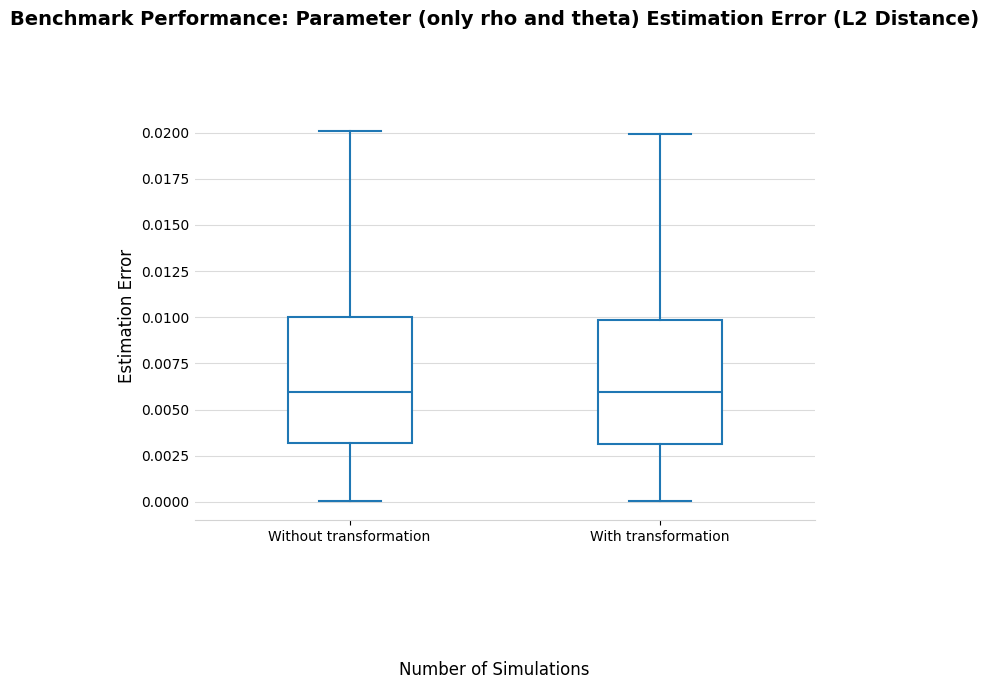

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: Parameter (only rho and theta) Estimation Error (L2 Distance)', fontsize=14, fontweight='bold', y=1.05)

raw_results = np.array([stage0_L2_noL[:, 6, :], stage0_logit_L2_noL])
x_positions = [0, 1]

arr = raw_results.copy()
arr_swapped = np.swapaxes(arr, 0, 2)
arr_flat = arr_swapped.reshape(-1, 2)

bplot = ax.boxplot(
    arr_flat,
    positions=x_positions,
    patch_artist=True,
    widths=0.4,
    showfliers=False
)

for patch in bplot['boxes']:
    patch.set_facecolor('white')
    patch.set_edgecolor('#1f77b4')
    patch.set_linewidth(1.5)
    
for element in ['whiskers', 'caps', 'medians']:
    for line in bplot[element]:
        line.set_color('#1f77b4')
        line.set_linewidth(1.5)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_groups, rotation=0)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.tick_params(axis='y', length=0)

ax.set_ylabel(r'Estimation Error', fontsize=12)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

Loaded posterior samples for seed 1 and n_sim 49948: shape (998, 500, 3)


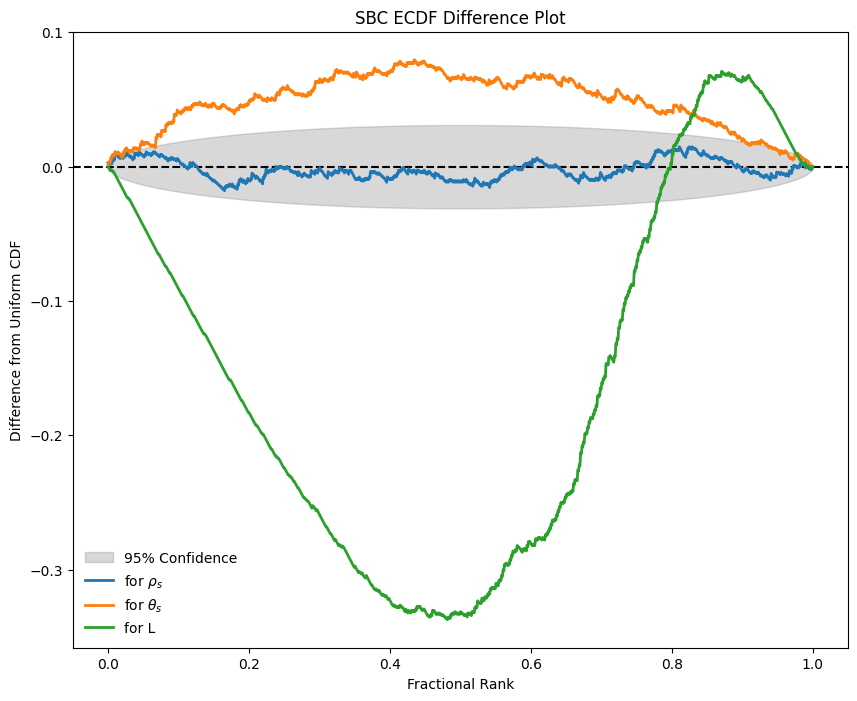

Loaded posterior samples for seed 2 and n_sim 49948: shape (998, 500, 3)


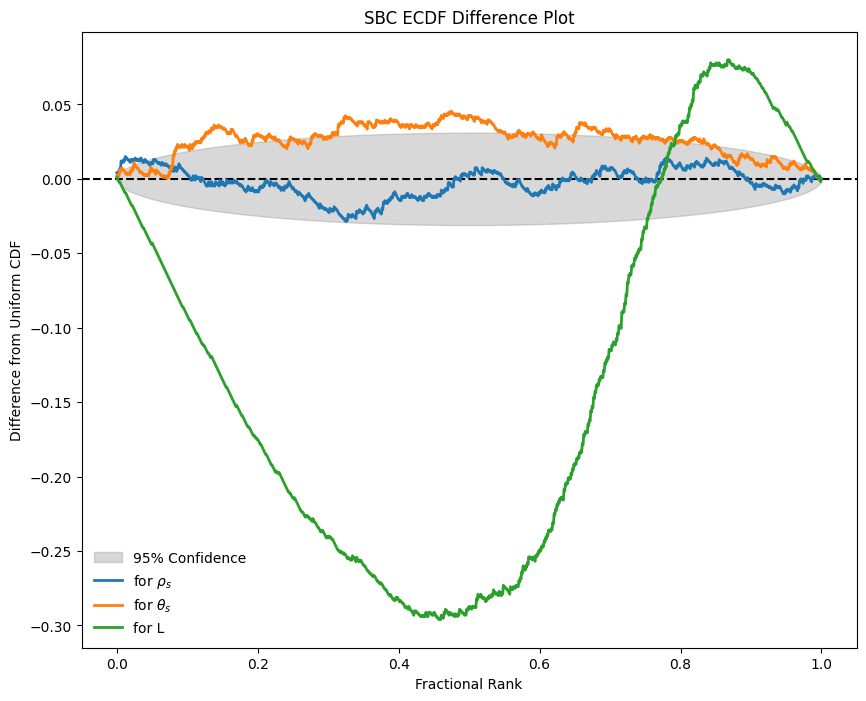

Loaded posterior samples for seed 3 and n_sim 49948: shape (998, 500, 3)


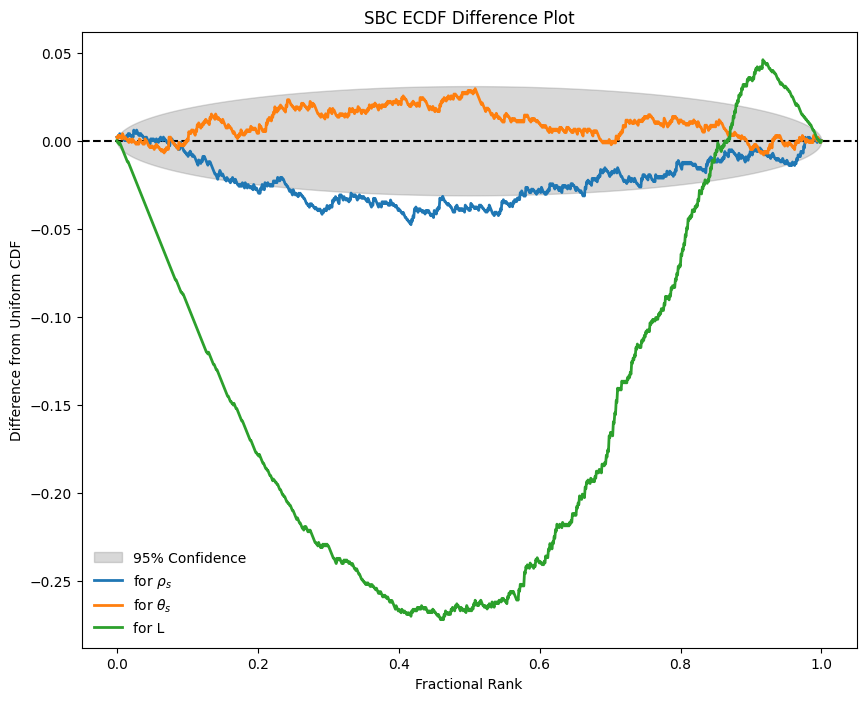

Loaded posterior samples for seed 4 and n_sim 49948: shape (998, 500, 3)


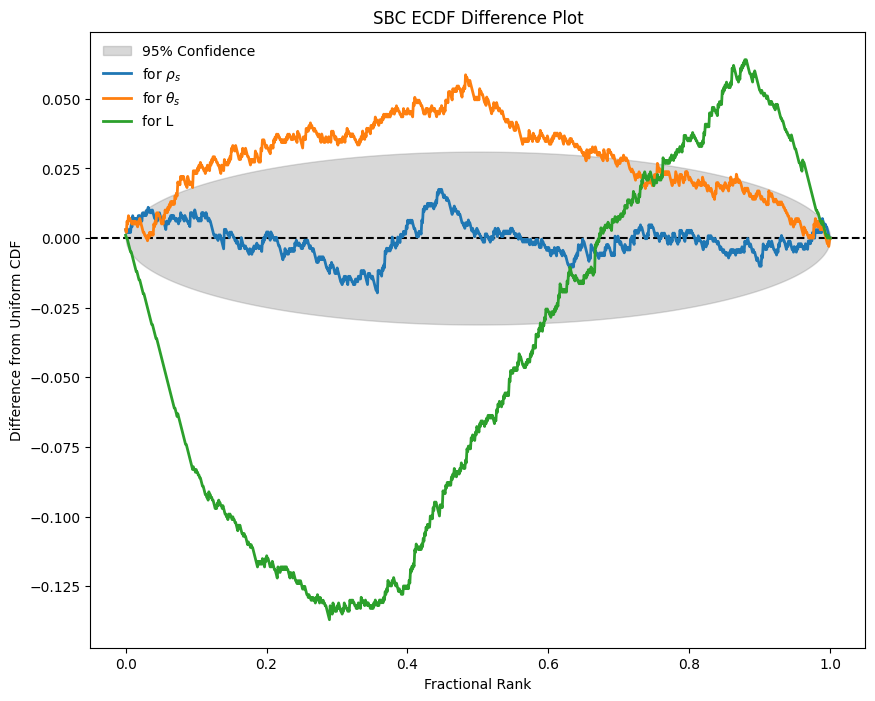

Loaded posterior samples for seed 9 and n_sim 49948: shape (998, 500, 3)


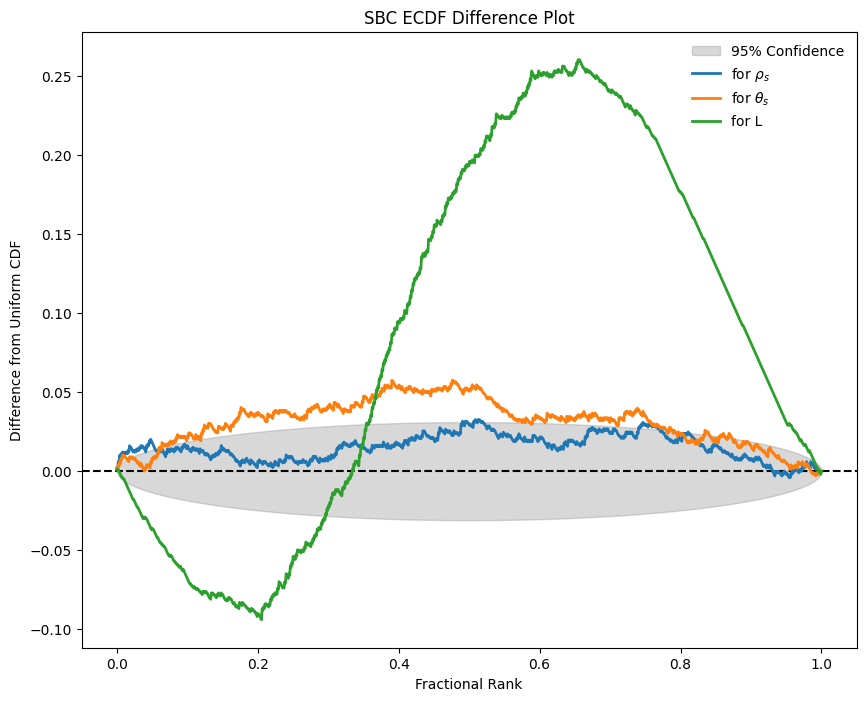

Loaded posterior samples for seed 10 and n_sim 49948: shape (998, 500, 3)


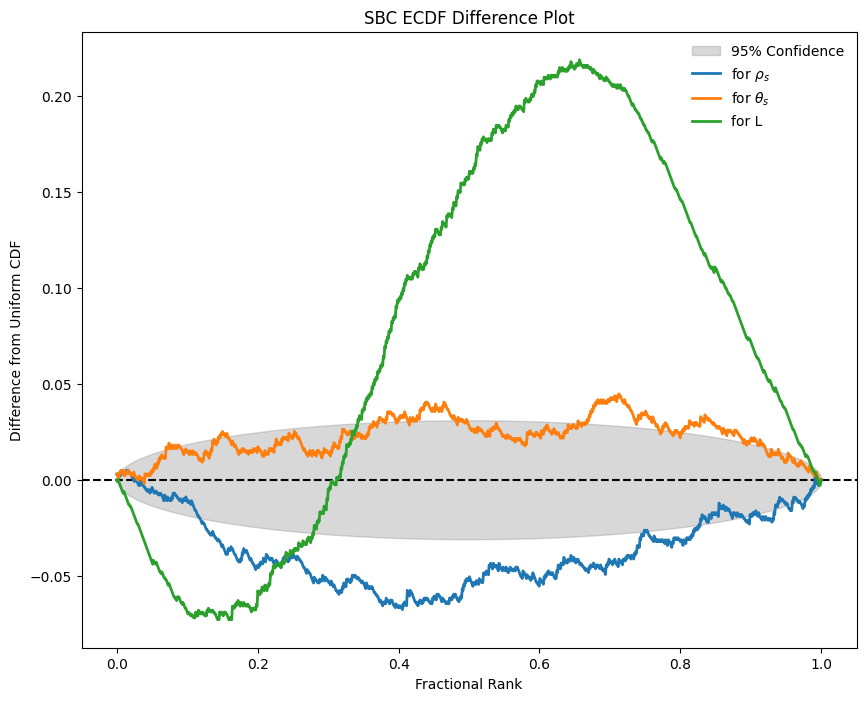

In [27]:
for i in miscal_indices_logit:
    seed = seeds[i]
    n_sim = 49948
    post_filename = f"../../data/benchmark_extension/npe_post_seed{seed}_sim{n_sim}_logit.npy"
    theta_est_post = np.load(post_filename)
    print(f"Loaded posterior samples for seed {seed} and n_sim {n_sim}: shape {theta_est_post.shape}")

    theta_est_post_back = np.full(theta_est_post.shape, np.nan)
    for j in range(theta_est_post.shape[0]):
        theta_iter_tensor = torch.tensor(theta_est_post[j, :, :], device=theta_test.device, dtype=theta_test.dtype)
        theta_iter_back = logit_to_bounded(
            theta_logit=theta_iter_tensor,
            low=low,
            high=high,
        )
        theta_est_post_back[j, :, :] = theta_iter_back.cpu().numpy()

    parameter_labels = [r"for $\rho_s$", r"for $\theta_s$", r"for L"]
    theta_test_expanded = theta_test.unsqueeze(1)
    theta_est_post_tensor = torch.tensor(theta_est_post_back, device=torch_device)
    theta_est_post_tensor = theta_est_post_tensor.to(torch.float32)
    is_less_than_truth = theta_est_post_tensor < theta_test_expanded
    ranks = torch.sum(is_less_than_truth, dim=1)
    plot_sbc_ecdf_diff(ranks.cpu().numpy(), 500, param_names=parameter_labels)